# Round 1 — Market Analysis

Products: **ASH_COATED_OSMIUM**, **INTARIAN_PEPPER_ROOT**  
Days: -2, -1, 0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Load datasets

In [3]:
DATASET_DIR = Path('../prosperity_rust_backtester/datasets/round1')

DAYS = [-2, -1, 0]

prices_frames = []
trades_frames = []

for day in DAYS:
    p = pd.read_csv(DATASET_DIR / f'prices_round_1_day_{day}.csv', sep=';')
    t = pd.read_csv(DATASET_DIR / f'trades_round_1_day_{day}.csv', sep=';')
    p['day'] = day
    t['day'] = day
    prices_frames.append(p)
    trades_frames.append(t)

prices = pd.concat(prices_frames, ignore_index=True)
trades = pd.concat(trades_frames, ignore_index=True)

# Synthetic global timestamp (each day has timestamps 0..999_900 in steps of 100)
prices['global_ts'] = (prices['day'] + 2) * 1_000_000 + prices['timestamp']
trades['global_ts'] = (trades['day'] + 2) * 1_000_000 + trades['timestamp']

print('Prices shape:', prices.shape)
print('Trades shape:', trades.shape)
print('Products:', prices['product'].unique())
prices.head()

Prices shape: (60000, 18)
Trades shape: (2276, 9)
Products: ['INTARIAN_PEPPER_ROOT' 'ASH_COATED_OSMIUM']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_ts
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,100
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,100
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0,200


In [4]:
prices['mid_price'] = prices['mid_price'].replace(0.0, np.nan)

prices['mid_price'] = (
    prices
    .sort_values('global_ts')
    .groupby('product')['mid_price']
    .transform(lambda s: s.interpolate(method='linear').ffill().bfill())
)

print('Remaining zeros:', (prices['mid_price'] == 0).sum())
print('Remaining NaNs:', prices['mid_price'].isna().sum())

Remaining zeros: 0
Remaining NaNs: 0


## 2. Mid-price evolution

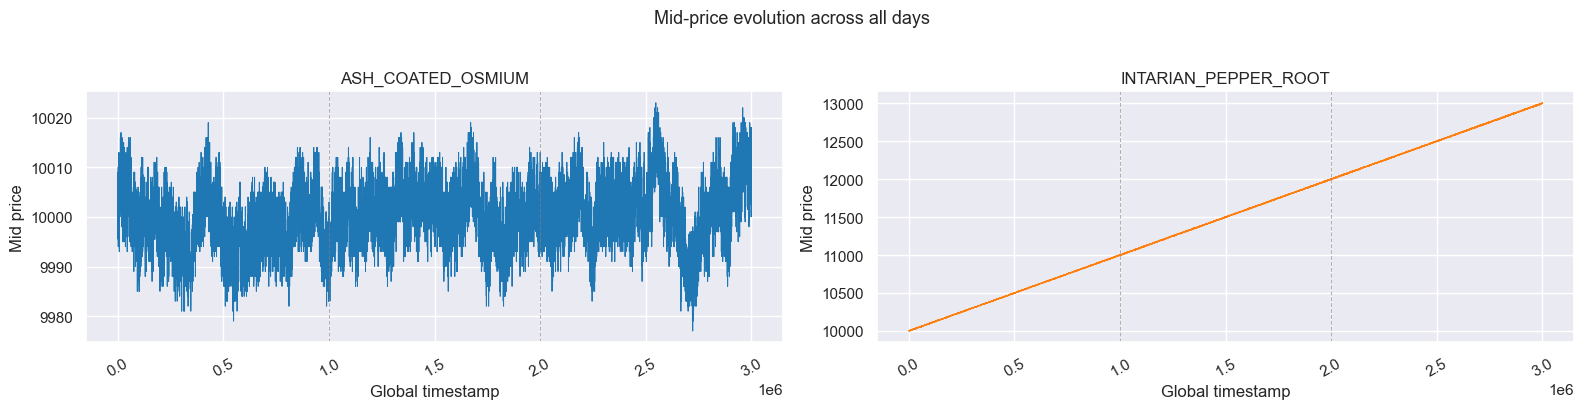

In [5]:
products = sorted(prices['product'].unique())
colors = sns.color_palette('tab10', len(products))

# products = sorted(prices['product'].unique())
# colors = sns.color_palette('tab10', len(products))

fig, axes = plt.subplots(1, len(products), sharey=False, figsize=(16, 4))

for ax, product, color in zip(axes, products, colors):
    df = prices[prices['product'] == product].sort_values('global_ts')
    ax.plot(df['global_ts'], df['mid_price'], lw=0.7, color=color)
    # Day separators
    for day in DAYS[1:]:
        sep = (day + 2) * 1_000_000
        ax.axvline(sep, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax.set_title(product)
    ax.set_xlabel('Global timestamp')
    ax.set_ylabel('Mid price')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Mid-price evolution across all days', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Summary statistics per product per day

In [6]:
stats = (
    prices.groupby(['product', 'day'])['mid_price']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .round(2)
)
stats['range'] = stats['max'] - stats['min']
stats

mean     std      min      max  count   range
product              day                                                   
ASH_COATED_OSMIUM    -2    9998.17    5.22   9979.0  10019.0  10000    40.0
                     -1   10000.84    4.45   9982.0  10019.0  10000    37.0
                      0   10001.61    5.68   9977.0  10023.0  10000    46.0
INTARIAN_PEPPER_ROOT -2   10499.94  288.70   9998.5  11003.0  10000  1004.5
                     -1   11499.95  288.72  10995.0  12006.0  10000  1011.0
                      0   12499.94  288.72  11994.0  13007.0  10000  1013.0

## 4. Bid-ask spread

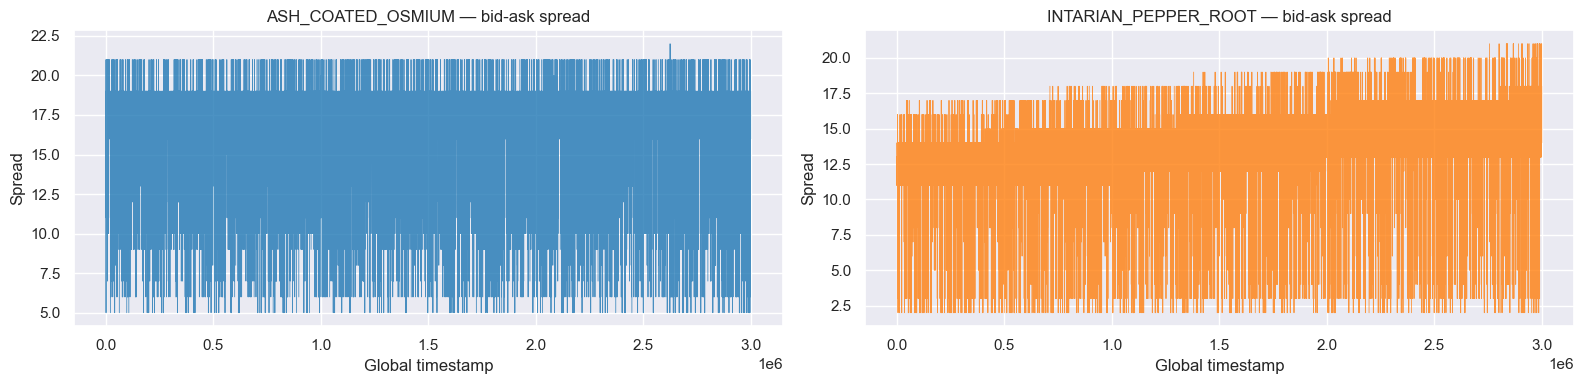

                        count   mean   std  min   25%   50%   75%   max
product                                                                
ASH_COATED_OSMIUM     27644.0  16.18  2.57  5.0  16.0  16.0  18.0  22.0
INTARIAN_PEPPER_ROOT  27688.0  13.05  2.63  2.0  12.0  13.0  14.0  21.0


In [7]:
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']

fig, axes = plt.subplots(1, len(products), figsize=(16, 4))
for ax, product, color in zip(axes, products, colors):
    df = prices[prices['product'] == product].sort_values('global_ts')
    ax.plot(df['global_ts'], df['spread'], lw=0.6, color=color, alpha=0.8)
    ax.set_title(f'{product} — bid-ask spread')
    ax.set_xlabel('Global timestamp')
    ax.set_ylabel('Spread')

plt.tight_layout()
plt.show()

print(prices.groupby('product')['spread'].describe().round(2))

## 5. Bid / Ask volume at level 1

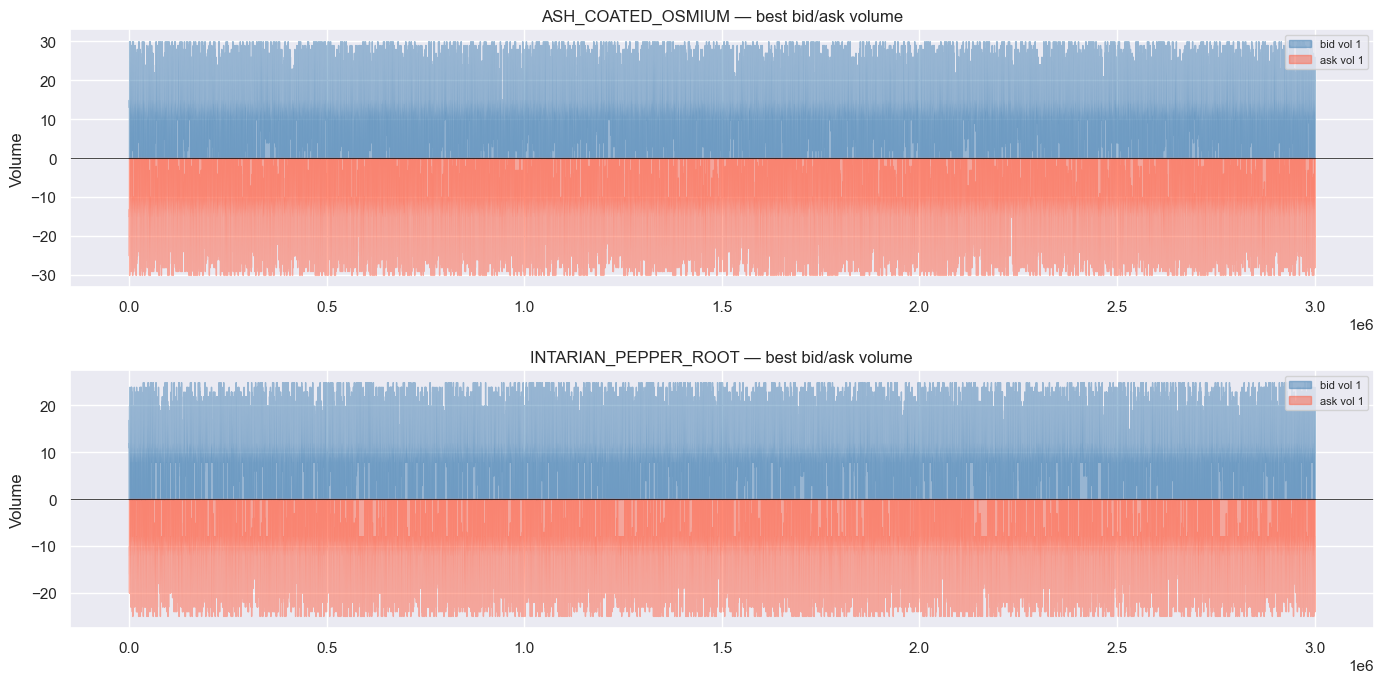

In [8]:
fig, axes = plt.subplots(len(products), 1, figsize=(14, 7), sharex=False)

for ax, product, color in zip(axes, products, colors):
    df = prices[prices['product'] == product].sort_values('global_ts')
    ax.fill_between(df['global_ts'], df['bid_volume_1'].fillna(0), alpha=0.5, label='bid vol 1', color='steelblue')
    ax.fill_between(df['global_ts'], -df['ask_volume_1'].fillna(0), alpha=0.5, label='ask vol 1', color='tomato')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f'{product} — best bid/ask volume')
    ax.set_ylabel('Volume')
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Correlation matrix — mid-prices (aligned on global_ts)

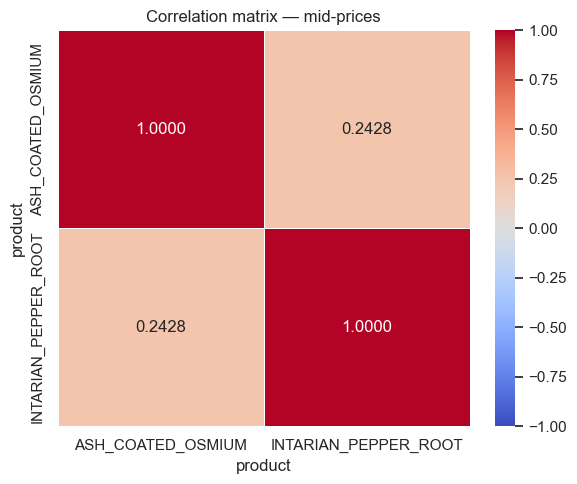

In [9]:
pivot = prices.pivot_table(index='global_ts', columns='product', values='mid_price')
pivot.ffill(inplace=True)

corr = pivot.corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt='.4f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Correlation matrix — mid-prices')
plt.tight_layout()
plt.show()

## 7. Rolling correlation (window = 500 ticks)

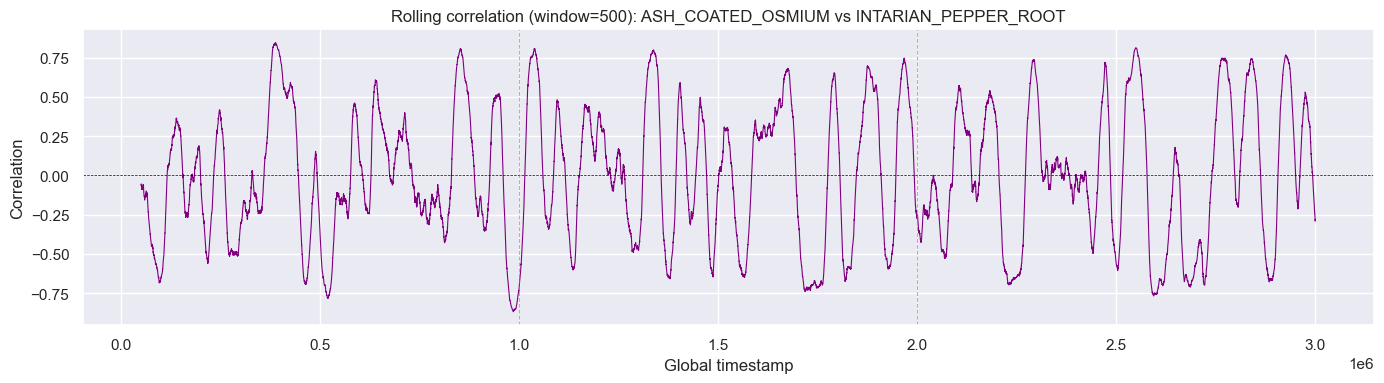

In [10]:
if len(products) >= 2:
    p0, p1 = products[0], products[1]
    rolling_corr = pivot[p0].rolling(500).corr(pivot[p1])

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(rolling_corr.index, rolling_corr.values, lw=0.8, color='purple')
    ax.axhline(0, color='black', lw=0.5, ls='--')
    for day in DAYS[1:]:
        ax.axvline((day + 2) * 1_000_000, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax.set_title(f'Rolling correlation (window=500): {p0} vs {p1}')
    ax.set_xlabel('Global timestamp')
    ax.set_ylabel('Correlation')
    plt.tight_layout()
    plt.show()
else:
    print('Only one product — rolling correlation skipped.')

## 8. Returns and return correlation

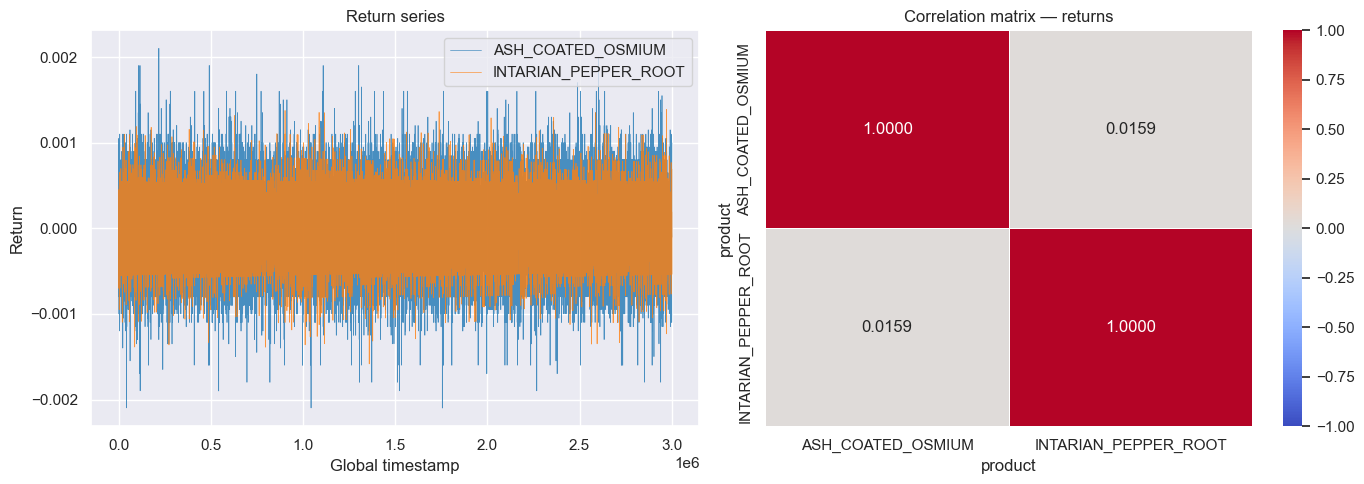

In [11]:
returns = pivot.pct_change().dropna()

ret_corr = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Return time series
for product, color in zip(products, colors):
    axes[0].plot(returns.index, returns[product], lw=0.5, label=product, color=color, alpha=0.8)
axes[0].set_title('Return series')
axes[0].set_xlabel('Global timestamp')
axes[0].set_ylabel('Return')
axes[0].legend()

# Return correlation heatmap
sns.heatmap(
    ret_corr, annot=True, fmt='.4f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5, ax=axes[1]
)
axes[1].set_title('Correlation matrix — returns')

plt.tight_layout()
plt.show()

## 9. Trade activity

In [ ]:
print('Trade counts per product per day:')
print(trades.groupby(['symbol', 'day']).size().unstack(fill_value=0))
print()
print('Trade price stats:')
trades.groupby(['symbol', 'day'])['price'].describe().round(2)

Trade counts per product per day:
day                    -2   -1    0
symbol                             
ASH_COATED_OSMIUM     429  425  411
INTARIAN_PEPPER_ROOT  344  335  332

Trade price stats:


count      mean     std      min       25%      50%  \
symbol               day                                                        
ASH_COATED_OSMIUM    -2   429.0   9998.20    9.22   9979.0   9990.00   9999.0   
                     -1   425.0  10000.77    9.10   9982.0   9993.00  10001.0   
                      0   411.0  10001.73    9.54   9981.0   9993.00  10002.0   
INTARIAN_PEPPER_ROOT -2   344.0  10495.70  286.98   9995.0  10243.00  10508.5   
                     -1   335.0  11503.09  285.80  10995.0  11263.50  11511.0   
                      0   332.0  12525.13  303.17  11998.0  12256.75  12532.0   

                              75%      max  
symbol               day                    
ASH_COATED_OSMIUM    -2   10006.0  10018.0  
                     -1   10009.0  10019.0  
                      0   10010.0  10026.0  
INTARIAN_PEPPER_ROOT -2   10747.5  10994.0  
                     -1   11749.5  12005.0  
                      0   12808.0  13005.0

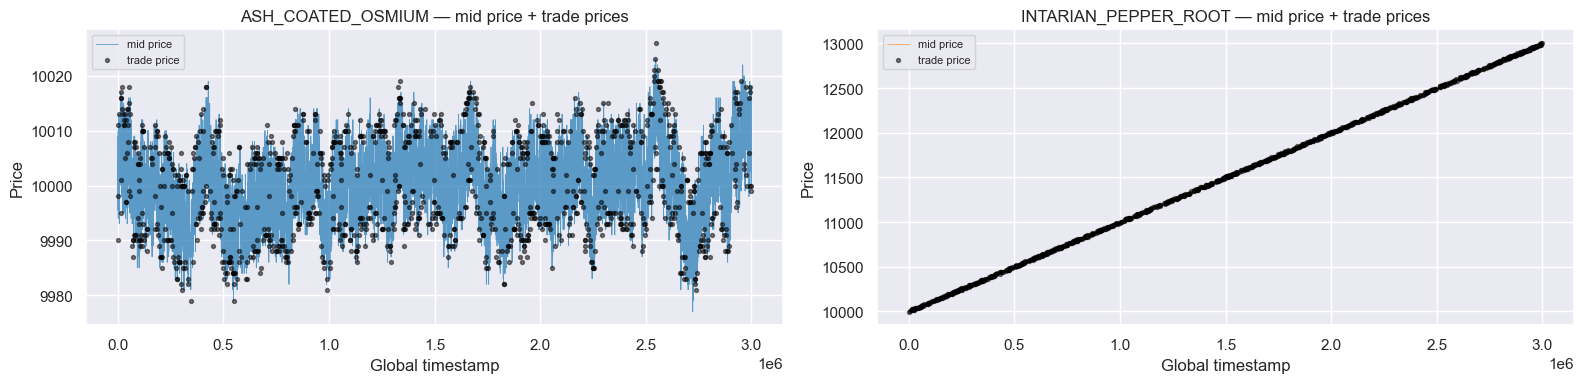

In [ ]:
fig, axes = plt.subplots(1, len(products), figsize=(16, 4))

for ax, product, color in zip(axes, products, colors):
    df_t = trades[trades['symbol'] == product].sort_values('global_ts')
    df_p = prices[prices['product'] == product].sort_values('global_ts')
    ax.plot(df_p['global_ts'], df_p['mid_price'], lw=0.6, color=color, alpha=0.7, label='mid price')
    ax.scatter(df_t['global_ts'], df_t['price'], s=8, color='black', alpha=0.5, label='trade price', zorder=5)
    ax.set_title(f'{product} — mid price + trade prices')
    ax.set_xlabel('Global timestamp')
    ax.set_ylabel('Price')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Trade volume distribution

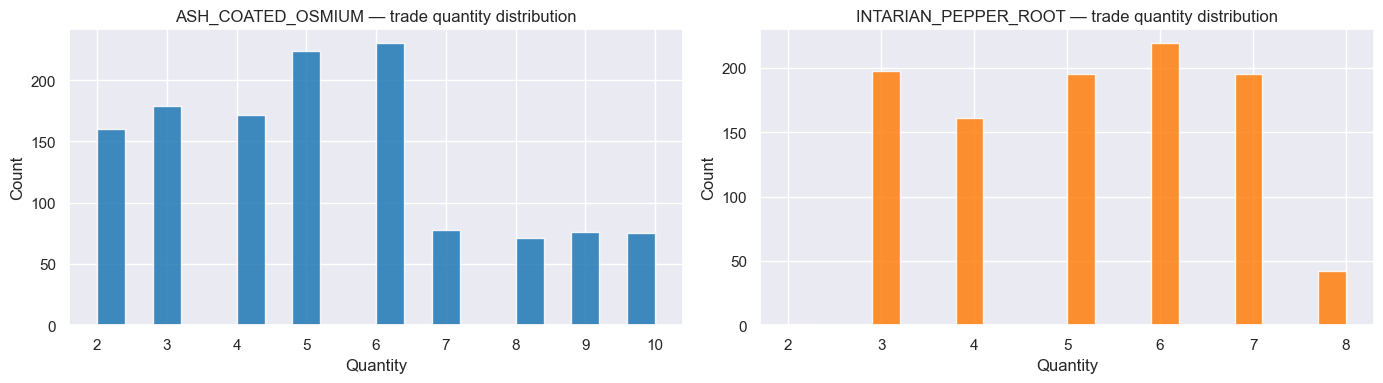

In [ ]:
fig, axes = plt.subplots(1, len(products), figsize=(14, 4))

for ax, product, color in zip(axes, products, colors):
    df_t = trades[trades['symbol'] == product]
    ax.hist(df_t['quantity'], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{product} — trade quantity distribution')
    ax.set_xlabel('Quantity')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()